![lop](../../images/logo_diive1_128px.png)

<span style='font-size:32px; display:block;'>
<b>
    Calculate flux detection limit from eddy covariance raw data files
</b>
</span>

---
**Notebook version**: `1` (10 Nov 2025)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Description**

- Calculates the flux detection limit from high-resolution (e.g., 20Hz) eddy covariance data

</br>

# **Imports**

In [1]:
import diive as dv
import importlib.metadata
import warnings
import pandas as pd
from datetime import datetime

warnings.filterwarnings("ignore")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# **Docstring**

In [2]:
help(dv.fdl)

Help on class FluxDetectionLimit in module diive.pkgs.echires.fluxdetectionlimit:

class FluxDetectionLimit(builtins.object)
 |  FluxDetectionLimit(df: pandas.core.frame.DataFrame, u_col: str, v_col: str, w_col: str, c_col: str, ts_col: str, h2o_col: str, press_col: str, default_lag: int, noise_range: int, lag_range: list, lag_stepsize: int, sampling_rate: int, show_covariance_plot: bool = True, title_covariance_plot: str = None)
 |  
 |  Calculates the flux detection limit from high-resolution eddy covariance data.
 |  
 |  This class implements the method described by Langford et al. (2015) to
 |  determine the flux detection limit (FDL) and signal-to-noise ratio for
 |  a given scalar flux (e.g., N2O, CH4).
 |  
 |  The FDL is calculated based on the noise in the cross-covariance function
 |  at large time lags, which are assumed to be uncorrelated with the turbulent
 |  flux. The flux noise is quantified as the Root Mean Square Error (RMSE)
 |  of the covariances in these "noise" w

</br>

# **Load example data**
- Load data from a 10Hz eddy covariance raw data file
- Keep required variables only
- `x`, `y`, `z` are the wind speeds from the sonic anemometer (`m s-1`)
- `N2Od` is the dry mole fraction (mixing ratio) of nitrous oxide (here originally in `umol mol-1`, but converted below to `nmol mol-1`)
- `Ts` is the sonic temperature (here originally in `degC`, but converted to `K` below)
- `H2O` is the measured water mole fraction (here originally in `umol mol-1`, but converted to `mol mol-1` below)
- `pressure` is the atmospheric pressure (`Pa`), here not available thus a constant is used

In [3]:
df = pd.read_csv('2023-06-24-03-30_LGRData.txt')
df = df[['x', 'y', 'z', 'N2Od', 'Ts', 'H2O']].copy()
df['pressure'] = 100000
df

,x,y,z,N2Od,Ts,H2O,pressure
0,-0.084,1.042,0.060,0.3465,11.912,11894.05,100000
1,-0.060,1.072,0.054,0.3459,11.905,11840.01,100000
2,-0.034,1.076,0.018,0.3466,11.882,11784.34,100000
3,-0.015,1.054,0.037,0.3462,11.896,11896.95,100000
4,-0.043,1.053,0.043,0.3466,11.891,11907.44,100000
...,...,...,...,...,...,...,...
17927,-0.511,1.380,-0.001,0.3433,12.132,12139.75,100000
17928,-0.581,1.386,0.095,0.3434,12.132,12019.64,100000
17929,-0.530,1.341,0.039,0.3434,12.125,12034.83,100000
17930,-0.581,1.207,0.156,0.3434,12.124,12079.91,100000


</br>

# **Convert to correct input units**

In [4]:
# Conversions
df['N2Od'] = df['N2Od'].multiply(10 ** 3)  # Convert from umol mol-1 to nmol mol-1
df['H2O'] = df['H2O'].div(10 ** 6)  # Convert from umol mol-1 to mol mol-1
df['Ts'] = df['Ts'].add(273.15)  # From degC to K
df

,x,y,z,N2Od,Ts,H2O,pressure
0,-0.084,1.042,0.060,346.5,285.062,0.011894,100000
1,-0.060,1.072,0.054,345.9,285.055,0.011840,100000
2,-0.034,1.076,0.018,346.6,285.032,0.011784,100000
3,-0.015,1.054,0.037,346.2,285.046,0.011897,100000
4,-0.043,1.053,0.043,346.6,285.041,0.011907,100000
...,...,...,...,...,...,...,...
17927,-0.511,1.380,-0.001,343.3,285.282,0.012140,100000
17928,-0.581,1.386,0.095,343.4,285.282,0.012020,100000
17929,-0.530,1.341,0.039,343.4,285.275,0.012035,100000
17930,-0.581,1.207,0.156,343.4,285.274,0.012080,100000


</br>

# **Calculate flux detection limit for `N2O` flux**
- Flux detection limit is returned in the respective flux units, here for N2O it is in `nmol m-2 s-1`

Time needed for covariance calculation: 3.208s
Flux noise RMSE: 0.6433393208791166
Flux detection limit: 1.9300179626373497


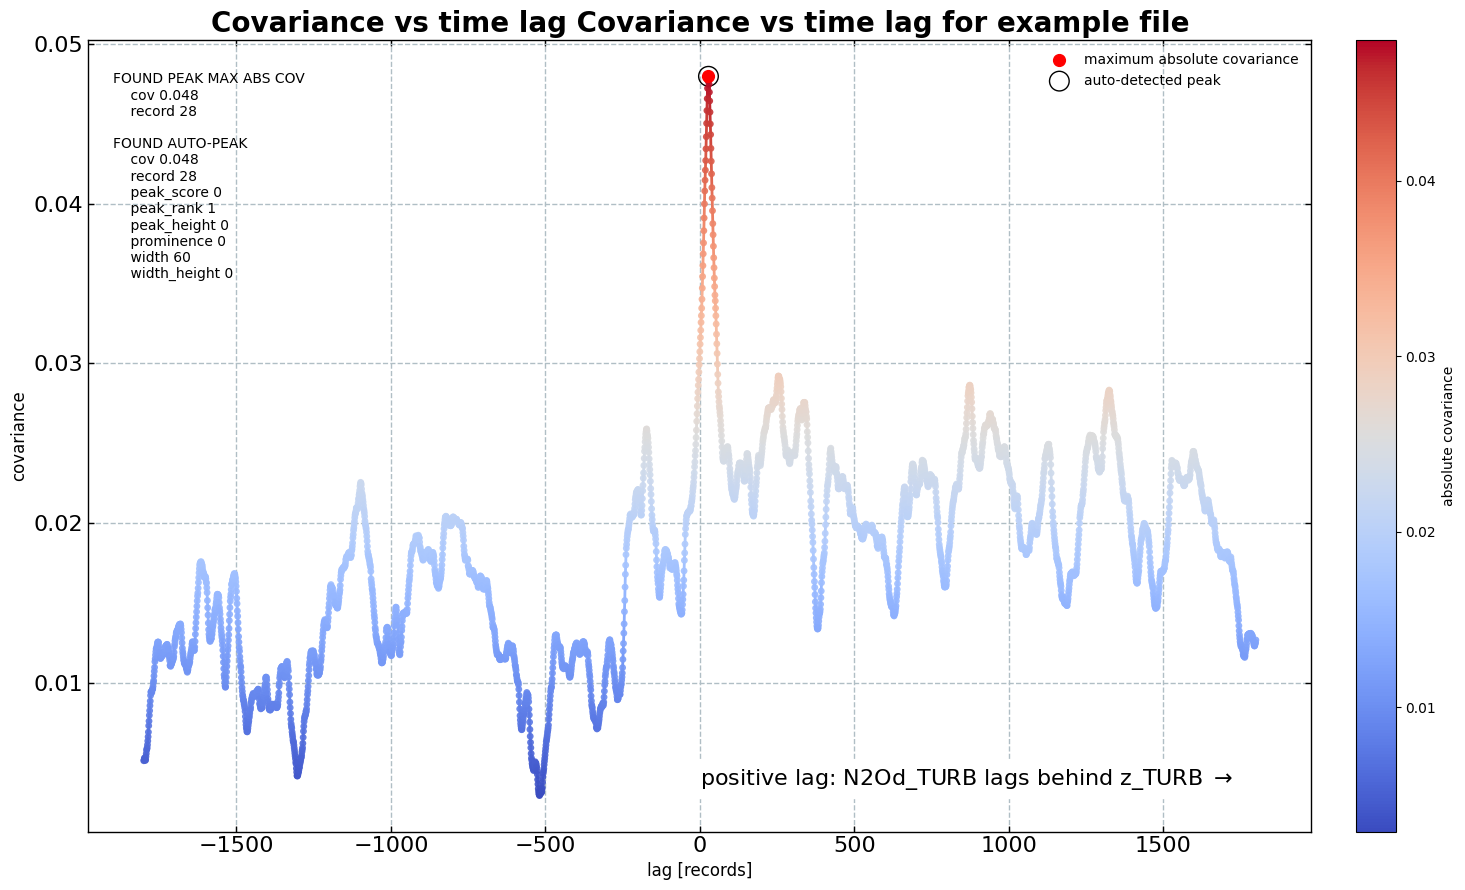

In [6]:
fdl = dv.FluxDetectionLimit(
    df=df,
    u_col='x',  # m s-1
    v_col='y',  # m s-1
    w_col='z',  # m s-1
    c_col='N2Od',  # nmol mol-1 (ppb)
    ts_col='Ts',  # degC
    h2o_col='H2O',  # mol mol-1
    press_col='pressure',  # Pa
    noise_range=20,  # seconds
    default_lag=2.8,  # seconds, calculate the "true" flux for this lag, used as "signal" in the signal-to-noise ratio
    lag_range=[-180, 180],  # seconds, calculate covariance for all steps between -180s and +180s
    lag_stepsize=1,  # number of records, step size for lag search
    sampling_rate=10,  # Hz
    show_covariance_plot=True,
    title_covariance_plot="Covariance vs time lag for example file")
fdl.run()
results = fdl.get_detection_limit()

**The covariance plot for the example file, showing the covariance at different time lags.**  

The turbulent flux of N2O was determined by analyzing the cross-covariance between vertical wind and N2O mixing ratio.  
For this 10 Hz dataset, the maximum covariance, or "signal," was identified at a time lag of −28 records (−2.8 seconds).  
This flux signal was then compared against the "noise," which was calculated using the Root Mean Square Error (RMSE) of  
the covariance in the far-lag windows (−180s to −160s and +160s to +180s, this corresponds to -1800 records to -1600 records,  
and +1600 records to +1800 records, respectively). The final flux detection limit is defined as three times this noise RMSE.  

The default lag can be freely defined and it does not have to be the point of maximum covariance. In this example, the default  
lag was chosen because it was known before hand that it is also the maximum covariance, and therefore the best reference for  
calculating the "signal".

In [7]:
results

{'flux_detection_limit': 1.9300179626373497,
 'flux_noise_rmse': 0.6433393208791166,
 'cov_max_ix': np.int64(1828),
 'cov_max_shift': np.int64(28),
 'flux_signal_at_default_lag': np.float64(0.8817597900162787),
 'signal_to_noise': np.float64(1.3705983163151958),
 'signal_to_detection_limit': np.float64(0.4568661054383986)}

</br>

# **End of notebook**

In [8]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-11-10 18:58:22
